__Overall Structure__

Model.py - Define PINN class:
- super init
- forward
- BC + IC + PINN loss = Total Loss

Data.py - Construct Training Points:
- BC's need points with x coordinates -1 or 1, any t value, producing y values of zero
- IC's need points with any x coordinates between [-1,1], t = 0, producing y values of sin(pi*x)
- Collocation points random x and t coordinates, y values from PDE

Train.py - Train the model using Adam (and optionally LBFGS):
- Define optimiser
- For loop: calculate loss, optimiser.zero_grad(), loss.backward(), optimiser.step()

Evaluate.py - How successful is the model? 
- Exact solution (from known solution to the Diffusion PDE)
- Relative error formula

First Test Experiments (IPYNB file)
- Imports
- Create data points, sanity check them
- Test x values at a fixed time
- Generate Heat Map + show relative error
- How does changing Number of collocation points affect 1.final loss 2.relative error 3. training time?

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import copy
import time

from src.model import PINN
from src.data import (
    generate_boundary_points,
    generate_initial_points,
    generate_collocation_points,
)
from src.train import train_pinn
from src.evaluate import exact_solution, relativeERROR

# Set default data type to float32
torch.set_default_dtype(torch.float)

# PyTorch random number generator
torch.manual_seed(1234)

# Numpy random number generator
np.random.seed(1234)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

if device.type == 'cuda':
    print(torch.cuda.get_device_name())

cpu


In [20]:
x_bc, y_bc = generate_boundary_points(100)
x_ic, y_ic = generate_initial_points(100)
col_points = generate_collocation_points(100)

torch.Size([100, 2]) torch.Size([100, 1])
torch.Size([100, 2]) torch.Size([100, 1])
torch.Size([100, 2])
torch.return_types.min(
values=tensor([-1.0000,  0.0065]),
indices=tensor([2, 9]))
torch.return_types.max(
values=tensor([1.0000, 0.9949]),
indices=tensor([ 0, 75]))
torch.float32
torch.float32
torch.float32
torch.float32
torch.float32


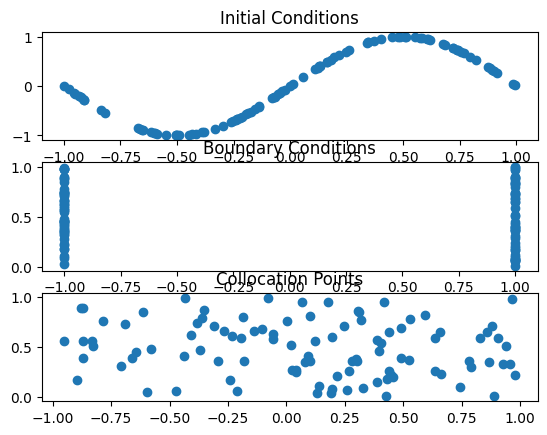

In [21]:
# Sanity Check

#should be (100,2) , (100,1)
print(x_bc.shape, y_bc.shape)
#should be (100,2) , (100,1)
print(x_ic.shape, y_ic.shape)
#should be (100,2)
print(col_points.shape)

#should be between -1 and 1
print(x_bc.min(dim=0))
print(x_bc.max(dim=0))

# Create Scatter Plot
fig, axs = plt.subplots(3)
axs[0].scatter(x_ic[:,[0]],y_ic)
axs[0].set_title('Initial Conditions')
axs[1].scatter(x_bc[:, [0]], x_bc[:, [1]])
axs[1].set_title('Boundary Conditions')
axs[2].scatter(col_points[:,[0]],col_points[:,[1]])
axs[2].set_title('Collocation Points')


print(x_bc.dtype)
print(y_bc.dtype)
print(x_ic.dtype)
print(y_ic.dtype)
print(col_points.dtype)

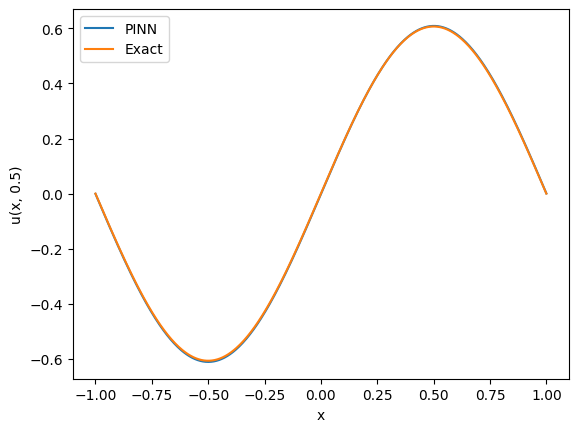

In [22]:
# At fixed time
x_values = torch.linspace(-1, 1, 500).reshape(-1, 1)
t_values = torch.ones((500, 1)) * 0.5
values = torch.hstack((x_values, t_values))

# Train PINN 
pinn = PINN()
history, final_loss = train_pinn(pinn,x_bc,y_bc,x_ic,y_ic,col_points)

# PINN predicted values
with torch.no_grad():
    predicted_values = pinn(values)

# Exact values using known solution
exact_values = exact_solution(x_values, t_values)

plt.plot(x_values, predicted_values, label="PINN")
plt.plot(x_values, exact_values, label="Exact")
plt.xlabel("x")
plt.ylabel("u(x, 0.5)")
plt.legend()
plt.show()

Text(0, 0.5, 't')

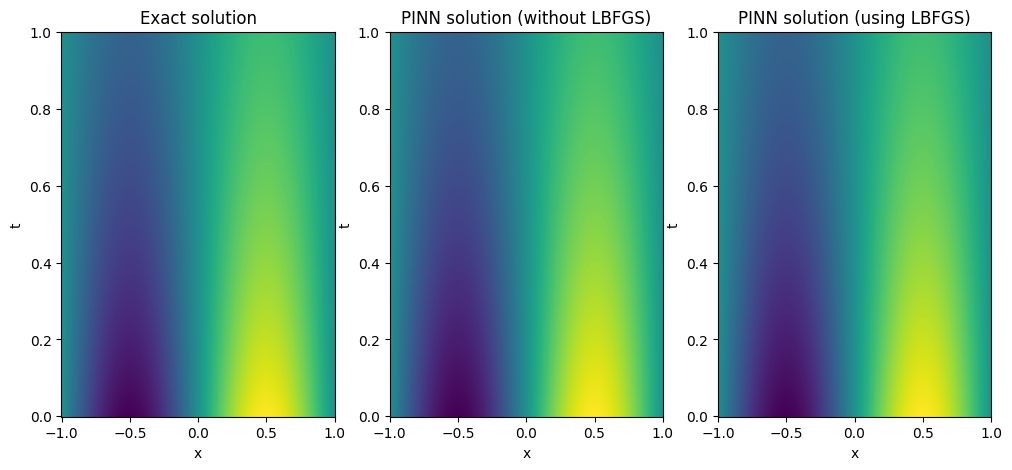

In [23]:
# Visualising PINN Prediction using heatmap
# Create Grid Points
x = torch.linspace(-1,1,500)
t = torch.linspace(0,1,500)
X, T = torch.meshgrid(x,t, indexing='ij')
grid = torch.hstack((
    X.reshape(-1, 1),
    T.reshape(-1, 1)))

# Create untrained PINN's all using the same inital state
pinn = PINN()
initial_pinn_state = copy.deepcopy(pinn.state_dict())

# Just using Adam to train
pinn_noLBFGS = PINN()
pinn_noLBFGS.load_state_dict(initial_pinn_state)
train_pinn(pinn_noLBFGS,x_bc,y_bc, x_ic, y_ic, col_points, use_LBFGS= False)
with torch.no_grad():
    predicted_values_noLBFGS = pinn_noLBFGS(grid)

# Using both Adam and LBFGS to train
pinn_LBFGS = PINN()
pinn_LBFGS.load_state_dict(initial_pinn_state)
train_pinn(pinn_LBFGS,x_bc,y_bc, x_ic, y_ic, col_points, use_LBFGS= True)
with torch.no_grad():
    predicted_values_LBFGS = pinn_LBFGS(grid)

# Exact values using known PDE solution
exact_values = exact_solution(grid[:,[0]], grid[:,[1]])

# Create Heatmap
fig, axs = plt.subplots(1,3, figsize = (12,5))
axs[0].pcolormesh(X,T,exact_values.reshape(X.shape))
axs[0].set_title('Exact solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')
axs[1].pcolormesh(X,T,predicted_values_noLBFGS.reshape(X.shape))
axs[1].set_title('PINN solution (without LBFGS)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')
axs[2].pcolormesh(X,T,predicted_values_LBFGS.reshape(X.shape))
axs[2].set_title('PINN solution (using LBFGS)')
axs[2].set_xlabel('x')
axs[2].set_ylabel('t')


Relative error without LBFGS: 0.015783
Relative error using LBFGS: 0.015422


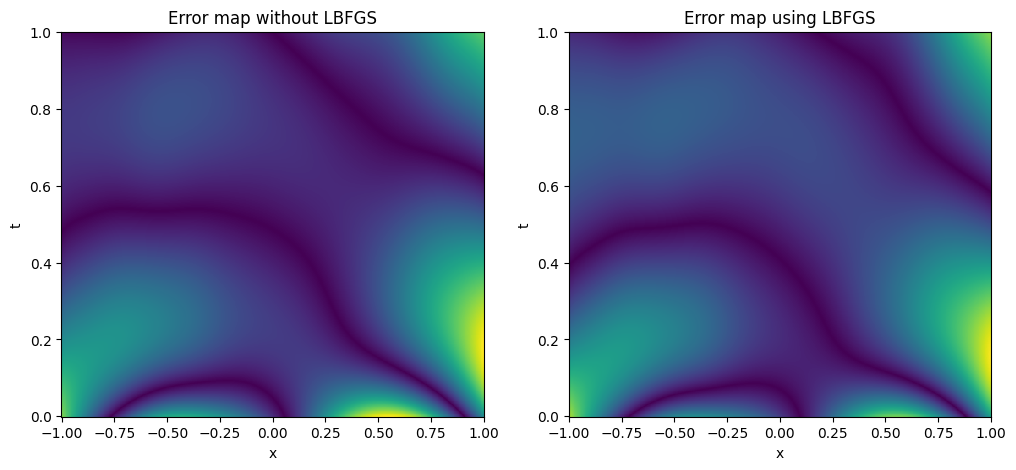

In [24]:
# Create Error Heatmap Comparing Relative Error with/without LBFGS
fig, axs = plt.subplots(1,2, figsize = (12,5))
axs[0].pcolormesh(X,T,np.abs(predicted_values_noLBFGS-exact_values).reshape(X.shape))
axs[0].set_title('Error map without LBFGS')
axs[0].set_xlabel('x')
axs[0].set_ylabel('t')
axs[1].pcolormesh(X,T,np.abs(predicted_values_LBFGS-exact_values).reshape(X.shape))
axs[1].set_title('Error map using LBFGS')
axs[1].set_xlabel('x')
axs[1].set_ylabel('t')


print(f"Relative error without LBFGS: {relativeERROR(predicted_values_noLBFGS,exact_values).item():.6f}")
print(f"Relative error using LBFGS: {relativeERROR(predicted_values_LBFGS,exact_values).item():.6f}")

Text(0, 0.5, 'Relative Error from exact grid solution')

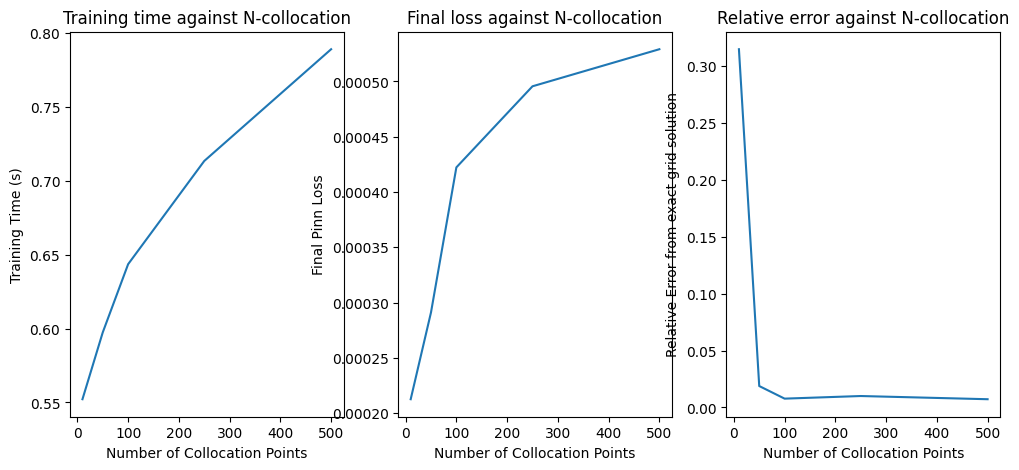

In [25]:
# Investigating how N-collocation affects:  1. training time 2. final loss 3. relative error 

# Experiment Setup
training_time_array = []
final_loss_array = []
relative_error_array = []
pinn = PINN()
initial_pinn_state = copy.deepcopy(pinn.state_dict())

# Exact solution to test against
exact_values = exact_solution(grid[:,[0]], grid[:,[1]])

# Train for different numbers of collocation points
N_collocation = [10,50,100,250,500]
for i in N_collocation:
     pinn = PINN()
     pinn.load_state_dict(initial_pinn_state)
     start_time = time.perf_counter()
     history, final_loss = train_pinn(pinn,x_bc,y_bc, x_ic,y_ic,generate_collocation_points(i))
     training_time = time.perf_counter() - start_time
     training_time_array.append(training_time)
     final_loss_array.append(final_loss.item())
     with torch.no_grad():
          predicted_values_LBFGS = pinn(grid)
     relative_error_array.append(relativeERROR(predicted_values_LBFGS,exact_values).item())

# Plotting
fig, axs = plt.subplots(1,3, figsize = (12,5))
axs[0].plot(N_collocation,training_time_array)
axs[0].set_title('Training time against N-collocation')
axs[0].set_xlabel('Number of Collocation Points')
axs[0].set_ylabel('Training Time (s)')
axs[1].plot(N_collocation,final_loss_array)
axs[1].set_title('Final loss against N-collocation')
axs[1].set_xlabel('Number of Collocation Points')
axs[1].set_ylabel('Final Pinn Loss')
axs[2].plot(N_collocation,relative_error_array)
axs[2].set_title('Relative error against N-collocation')
axs[2].set_xlabel('Number of Collocation Points')
axs[2].set_ylabel('Relative Error from exact grid solution')